# Objectif du fichier

Analyse descriptive des résultats du clusturing selon les années.
Pour cela plusieurs étapes:
- on récupères les données clusterisées.
- on calcule les différentes métriques pour chaque années.
- on passe à l'année suivante.

Les métriques d'intérêt pour les statistiques descriptives sont : évolution de la surface industrialisée, évolution du nombre de clusters, proportion des bâtiments isolés, nombre de meta clusters, raux de conversion d'une année sur l'autre des points isolés en cluster.

In [4]:
!pip install geopandas pandas numpy shapely matplotlib requests beautifulsoup4 boto3 py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 19.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 35.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 30.6 MB/s  0:00:00
  Attempting uninstall: botocore━━╸━━━━━━━━━━━━━  8/12 [py7zr]todomex]
    Found existing installation: botocore 1.40.49━━━━━━━━━━━━━  8/12 [py7zr]
    Uninstalling botocore-1.40.49:╸━━━━━━━━━━━━━  8/12 [py7zr]
      Successfully uninstalled botocore-1.40.49╺━━━━━━━━━  9/12 [botocore]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [boto3]m11/12 [boto3]re]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.25.0 requires botocore<1.40.50,>=1.40.46, but you have botocore 1.40.60 which is incompatible.


In [104]:
### TELECHARGEMENT PACKAGES
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import requests
from bs4 import BeautifulSoup
import re
import os
import subprocess
import boto3
import tempfile
import py7zr 
import glob
from credentials import s3
from fonctions import load_gpkg, gdf_DBSCAN, plot_DB_epsilon, courbe_DB_epsilon
from fonctions import download_to_SSPCloud


In [105]:
def load_gpkg(remote_path: str,bucket="mgarbe") -> gpd.GeoDataFrame:
    """
    Télécharge un fichier GeoPackage (.gpkg) depuis Onyxia/SSPCloud et le charge dans un GeoDataFrame.
    """

    s3 = boto3.client("s3",endpoint_url = 'https://'+'minio.lab.sspcloud.fr',
                  aws_access_key_id= '3OSR238EXXV9XU9TSPQ4', 
                  aws_secret_access_key= 'CMp5VCaD5F0WKxCaCibrHiNBUwwoUU+og5jwCHOu', 
                  aws_session_token = 'eyJhbGciOiJIUzUxMiIsInR5cCI6IkpXVCJ9.eyJhY2Nlc3NLZXkiOiIzT1NSMjM4RVhYVjlYVTlUU1BRNCIsImFsbG93ZWQtb3JpZ2lucyI6WyIqIl0sImF1ZCI6WyJtaW5pby1kYXRhbm9kZSIsIm9ueXhpYSIsImFjY291bnQiXSwiYXV0aF90aW1lIjoxNzYxNjYwMDU3LCJhenAiOiJvbnl4aWEiLCJlbWFpbCI6Im1hdGVvLmdhcmJlQGVuc2FlLmZyIiwiZW1haWxfdmVyaWZpZWQiOnRydWUsImV4cCI6MTc2MjI2NDg2OCwiZmFtaWx5X25hbWUiOiJHYXJiZSIsImdpdmVuX25hbWUiOiJNYXTDqW8iLCJncm91cHMiOlsiVVNFUl9PTllYSUEiXSwiaWF0IjoxNzYxNjYwMDY4LCJpc3MiOiJodHRwczovL2F1dGgubGFiLnNzcGNsb3VkLmZyL2F1dGgvcmVhbG1zL3NzcGNsb3VkIiwianRpIjoib25ydHJ0OmY1NmM4MGQ4LWQzOTQtYjc1NS00YmE0LTdjYjA4YzBjYmY0MiIsIm5hbWUiOiJNYXTDqW8gR2FyYmUiLCJwb2xpY3kiOiJzdHNvbmx5IiwicHJlZmVycmVkX3VzZXJuYW1lIjoibWdhcmJlIiwicmVhbG1fYWNjZXNzIjp7InJvbGVzIjpbIm9mZmxpbmVfYWNjZXNzIiwidW1hX2F1dGhvcml6YXRpb24iLCJkZWZhdWx0LXJvbGVzLXNzcGNsb3VkIl19LCJyZXNvdXJjZV9hY2Nlc3MiOnsiYWNjb3VudCI6eyJyb2xlcyI6WyJtYW5hZ2UtYWNjb3VudCIsIm1hbmFnZS1hY2NvdW50LWxpbmtzIiwidmlldy1wcm9maWxlIl19fSwicm9sZXMiOlsib2ZmbGluZV9hY2Nlc3MiLCJ1bWFfYXV0aG9yaXphdGlvbiIsImRlZmF1bHQtcm9sZXMtc3NwY2xvdWQiXSwic2NvcGUiOiJvcGVuaWQgcHJvZmlsZSBncm91cHMgZW1haWwiLCJzaWQiOiI1MGQ3MWMxZS00YTQxLTRlM2EtYWU2NC1iNGQ0YmJmNmVkNzUiLCJzdWIiOiIxMDE2NTkyZC1lMDA1LTRiNDItYjViYy1mODVhZDBiODgyZjUiLCJ0eXAiOiJCZWFyZXIifQ.IIKCBugdwsz12LG28UF-kKOsRQA9Utb1cE6za6QiDoMPeDy-HwvfCKShE1HAELvUMgtnHUkGKc810oi9CU2Xzg')
    # Chemin temporaire local
    local_path = f"/tmp/{os.path.basename(remote_path)}"

    try:
        # Téléchargement
        print(f"Téléchargement depuis {bucket}/{remote_path} ...")
        s3.download_file(bucket, remote_path, local_path)

        # Chargement avec geopandas
        gdf = gpd.read_file(local_path)
        print(f"Chargement réussi ({len(gdf)} lignes)")

        return gdf

    except Exception as e:
        print(f"Erreur lors du chargement : {e}")
        return None

In [84]:
gdf.columns

Index(['Annee', 'Dep', 'ORIGIN_BAT', 'NATURE', 'HAUTEUR', 'USAGE1', 'USAGE2',
       'ETAT', 'DATE_CREAT', 'DATE_MAJ', 'ID_SOURCE', 'SOURCE', 'geometry'],
      dtype='object')

In [106]:
gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")


Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg ...
Chargement réussi (2958999 lignes)


,Annee,Dep,ORIGIN_BAT,NATURE,HAUTEUR,USAGE1,USAGE2,ETAT,DATE_CREAT,DATE_MAJ,ID_SOURCE,SOURCE,geometry
0,2013,81,Autre,Bâtiment commercial,10.0,None,None,None,None,None,None,None,"POLYGON Z ((636257 6317120.1 177.3, 636269.5 6..."
1,2013,81,Autre,Bâtiment commercial,9.0,None,None,None,None,None,None,None,"POLYGON Z ((632205 6317714.2 171.8, 632154.6 6..."
2,2013,81,Autre,Bâtiment commercial,5.0,None,None,None,None,None,None,None,"POLYGON Z ((633859 6295132 224.9, 633885 62951..."
3,2013,81,Autre,Bâtiment commercial,6.0,None,None,None,None,None,None,None,"POLYGON Z ((634089.4 6297169.6 212.7, 634141.8..."
4,2013,81,Autre,Bâtiment commercial,7.0,None,None,None,None,None,None,None,"POLYGON Z ((609820.8 6311188.5 145, 609796.1 6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958994,2025,95,Cadastre,"Industriel, agricole ou commercial",2.6,Industriel,Commercial et services,En service,2024-11-25 09:51:50,None,None,None,"POLYGON Z ((655332.9 6873423.6 52.1, 655348.9 ..."
2958995,2025,95,Cadastre,"Industriel, agricole ou commercial",2.6,Industriel,Commercial et services,En service,2024-11-25 09:51:52,None,None,None,"POLYGON Z ((655536.9 6873536.2 52.1, 655559.7 ..."
2958996,2025,95,None,"Industriel, agricole ou commercial",NaN,Industriel,None,En service,2025-01-09 17:30:56,None,None,None,"POLYGON Z ((634914.9 6902959.3 -1000, 634918 6..."
2958997,2025,95,None,"Industriel, agricole ou commercial",NaN,Industriel,None,En service,2025-01-13 18:03:47,None,None,None,"POLYGON Z ((669018.8 6892438 -1000, 669002.7 6..."


Progress: 15/15 | eps : 281, clusters : 0.894, isolés : 0.106


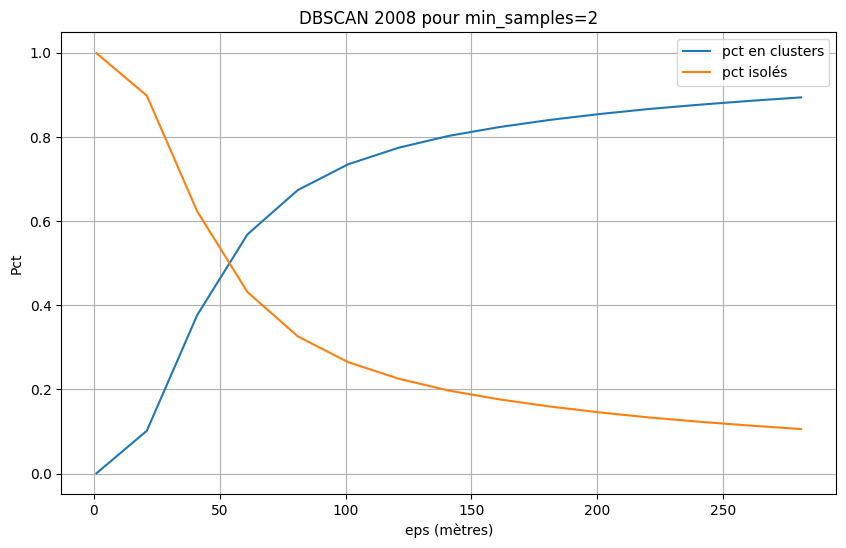

In [107]:
plot_DB_epsilon(gdf,2008,4,1,301,20)

In [64]:
a

3975

In [67]:
#######
####### ON FIXE LES PARAMETRES : A MODIFIER
#######

epsilon_petit = 50
epsilon_grand = 1000
m_sample = 4

On segmente par groupes de 20 départements. On fait tout le process et on stocke. Puis à la fin on aggrège selon tous les départements. Pour les proportions, l'aggrégation se fait à la fin.

In [ ]:
####Fonction meta cluster : test en local avant de mettre dans fonctions

import numpy as np
import pandas as pd
import geopandas as gpd
from sklearn.cluster import DBSCAN

def gdf_meta_DBSCAN(gdf: gpd.GeoDataFrame,
                    annee: int,
                    eps1: float,
                    eps2: float,
                    min_sample: int = 4):
    # 1) Filtre année
    gdf_annee = gdf[gdf["Annee"] == annee].copy()
    if len(gdf_annee) == 0:
        gdf_annee["centroid"] = pd.Series(dtype="object")
        gdf_annee["id_cluster"] = pd.Series(dtype="int64")
        gdf_annee["id_meta_cluster"] = pd.Series(dtype="int64")
        return gdf_annee, dict(n_clusters_lvl1=0, n_noise_lvl1=0,
                               n_meta_clusters=0, n_meta_noise=0)

    # 2) CRS métrique
    if gdf_annee.crs is None or not gdf_annee.crs.is_projected:
        gdf_annee = gdf_annee.to_crs(2154)

    # 3) Centroids
    gdf_annee["centroid"] = gdf_annee.geometry.centroid
    coords = np.column_stack([gdf_annee["centroid"].x.values,
                              gdf_annee["centroid"].y.values])

    # 4) DBSCAN niveau 1
    db1 = DBSCAN(eps=eps1, min_samples=min_sample)
    labels1 = db1.fit_predict(coords)
    gdf_annee["id_cluster"] = labels1.astype(int)

    n_clusters_lvl1 = int(len(set(labels1)) - (1 if -1 in labels1 else 0))
    n_noise_lvl1 = int(np.sum(labels1 == -1))

    # 5) Barycentres (clusters != -1)
    mask_clusters = (gdf_annee["id_cluster"].values != -1)  # <-- bool np.array
    if mask_clusters.any():
        df_centroids = (
            gdf_annee.loc[mask_clusters, ["id_cluster", "centroid"]]
            .assign(x=lambda d: d["centroid"].x,
                    y=lambda d: d["centroid"].y)
            .groupby("id_cluster", as_index=False)[["x", "y"]].mean()
        )

        # 6) DBSCAN niveau 2 sur barycentres
        bary_coords = np.column_stack([df_centroids["x"].values, df_centroids["y"].values])
        db2 = DBSCAN(eps=eps2, min_samples=min_sample)
        labels2 = db2.fit_predict(bary_coords)

        # 7) Remappage des labels de méta-clusters en 0..K-1 (en conservant -1)
        uniq = sorted([l for l in set(labels2) if l != -1])
        remap = {old: new for new, old in enumerate(uniq)}
        meta_labels = pd.Series(labels2).map(remap).fillna(-1).astype(int).to_numpy()

        # 8) Propagation aux entités d'origine
        meta_map = dict(zip(df_centroids["id_cluster"].astype(int).tolist(),
                            meta_labels.tolist()))
        gdf_annee["id_meta_cluster"] = gdf_annee["id_cluster"].map(meta_map).fillna(-1).astype(int)

        # Les bruits niveau 1 restent -1 (sans .loc avec ~mask ; approche .where)
        gdf_annee["id_meta_cluster"] = gdf_annee["id_meta_cluster"].where(
            gdf_annee["id_cluster"] != -1, -1
        ).astype(int)

        n_meta_clusters = int(len(uniq))
        n_meta_noise = int(np.sum(labels2 == -1))
    else:
        # Aucun cluster niveau 1
        gdf_annee["id_meta_cluster"] = -1
        n_meta_clusters, n_meta_noise = 0, 0

    # (optionnel) logs
    print(f"[Niveau 1] Clusters: {n_clusters_lvl1} | Bruit: {n_noise_lvl1}")
    print(f"[Niveau 2] Méta-clusters: {n_meta_clusters} | Bruit (barycentres): {n_meta_noise}")

    return gdf_annee, dict(
        n_clusters_lvl1=n_clusters_lvl1,
        n_noise_lvl1=n_noise_lvl1,
        n_meta_clusters=n_meta_clusters,
        n_meta_noise=n_meta_noise
    )


        


#### TEST

test , stat = gdf_meta_DBSCAN(gdf,
                    annee =  2008,
                    eps1 =  50,
                    eps2 =  1000,
                    min_sample= 5)

In [83]:
stat["n_clusters_lvl1"]

8849

In [ ]:
#### département 1 à 20

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_1_20.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf1 = []
nbclust1 = []
nbmeta1 = []
nbisole1 = []
nbconv1 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf1.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust1.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta1.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole1.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard
    


In [89]:
#### département 21 à 40

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf2 = []
nbclust2 = []
nbmeta2 = []
nbisole2 = []
nbconv2 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf2.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust2.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta2.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole2.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_21_40.gpkg ...
Chargement réussi (5532961 lignes)
[Niveau 1] Clusters: 10272 | Bruit: 346627
[Niveau 2] Méta-clusters: 403 | Bruit (barycentres): 7110
[Niveau 1] Clusters: 9350 | Bruit: 346752
[Niveau 2] Méta-clusters: 369 | Bruit (barycentres): 6720
[Niveau 1] Clusters: 10927 | Bruit: 345651
[Niveau 2] Méta-clusters: 442 | Bruit (barycentres): 7369
[Niveau 1] Clusters: 10272 | Bruit: 346627
[Niveau 2] Méta-clusters: 403 | Bruit (barycentres): 7110
[Niveau 1] Clusters: 11654 | Bruit: 348889
[Niveau 2] Méta-clusters: 493 | Bruit (barycentres): 7626
[Niveau 1] Clusters: 10927 | Bruit: 345651
[Niveau 2] Méta-clusters: 442 | Bruit (barycentres): 7369
[Niveau 1] Clusters: 11654 | Bruit: 348889
[Niveau 2] Méta-clusters: 493 | Bruit (barycentres): 7626
[Niveau 1] Clusters: 17012 | Bruit: 317328
[Niveau 2] Méta-clusters: 752 | Bruit (barycentres): 9801
[Niveau 1] Clusters: 18189 | Bruit: 309381
[Niveau 2] Méta-clusters: 804 | Bruit (bar

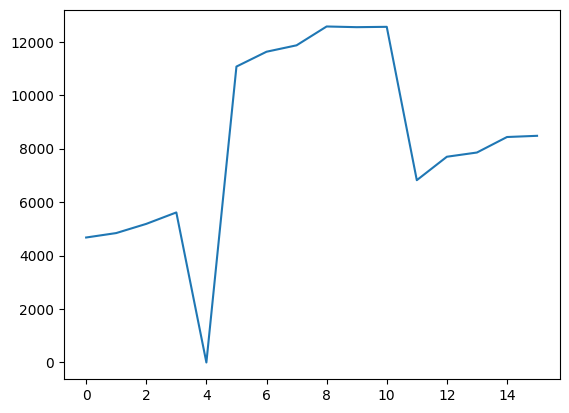

In [93]:
plt.plot(nbclust)

In [94]:
#### département 41 à 60

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf3 = []
nbclust3 = []
nbmeta3 = []
nbisole3 = []
nbconv3 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf3.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust3.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta3.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole3.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_41_60.gpkg ...
Chargement réussi (6183558 lignes)
[Niveau 1] Clusters: 10635 | Bruit: 379440
[Niveau 2] Méta-clusters: 409 | Bruit (barycentres): 7178
[Niveau 1] Clusters: 9976 | Bruit: 381921
[Niveau 2] Méta-clusters: 374 | Bruit (barycentres): 7036
[Niveau 1] Clusters: 11271 | Bruit: 381960
[Niveau 2] Méta-clusters: 417 | Bruit (barycentres): 7689
[Niveau 1] Clusters: 10635 | Bruit: 379440
[Niveau 2] Méta-clusters: 409 | Bruit (barycentres): 7178
[Niveau 1] Clusters: 11310 | Bruit: 378653
[Niveau 2] Méta-clusters: 414 | Bruit (barycentres): 7663
[Niveau 1] Clusters: 11271 | Bruit: 381960
[Niveau 2] Méta-clusters: 417 | Bruit (barycentres): 7689
[Niveau 1] Clusters: 11310 | Bruit: 378653
[Niveau 2] Méta-clusters: 414 | Bruit (barycentres): 7663
[Niveau 1] Clusters: 24365 | Bruit: 331283
[Niveau 2] Méta-clusters: 918 | Bruit (barycentres): 9574
[Niveau 1] Clusters: 24840 | Bruit: 320721
[Niveau 2] Méta-clusters: 943 | Bruit (bar

In [95]:
#### département 61 à 80

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf4 = []
nbclust4 = []
nbmeta4 = []
nbisole4 = []
nbconv4 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des clusters
    surf4.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust4.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta4.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole4.append(stat["n_noise_lvl1"])

    ## nb conv : On verra pour l'implémenter plus tard

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_61_80.gpkg ...
Chargement réussi (5907821 lignes)
[Niveau 1] Clusters: 8397 | Bruit: 322980
[Niveau 2] Méta-clusters: 340 | Bruit (barycentres): 5142
[Niveau 1] Clusters: 7488 | Bruit: 324000
[Niveau 2] Méta-clusters: 293 | Bruit (barycentres): 4935
[Niveau 1] Clusters: 10988 | Bruit: 331479
[Niveau 2] Méta-clusters: 420 | Bruit (barycentres): 6167
[Niveau 1] Clusters: 8397 | Bruit: 322980
[Niveau 2] Méta-clusters: 340 | Bruit (barycentres): 5142
[Niveau 1] Clusters: 14236 | Bruit: 319104
[Niveau 2] Méta-clusters: 575 | Bruit (barycentres): 6576
[Niveau 1] Clusters: 10988 | Bruit: 331479
[Niveau 2] Méta-clusters: 420 | Bruit (barycentres): 6167
[Niveau 1] Clusters: 14236 | Bruit: 319104
[Niveau 2] Méta-clusters: 575 | Bruit (barycentres): 6576
[Niveau 1] Clusters: 18165 | Bruit: 296559
[Niveau 2] Méta-clusters: 781 | Bruit (barycentres): 7387
[Niveau 1] Clusters: 19106 | Bruit: 294409
[Niveau 2] Méta-clusters: 842 | Bruit (baryc

In [205]:
#### département 81 à 99

gdf=load_gpkg("BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg")

## création des listes
annees = list(range(2009,2025)) ## Pour l'instant on simplifie en enlevant la première année, on pourra raffiner plus tard
surf5 = []
nbclust5 = []
nbmeta5 = []
nbisole5 = []
nbconv5 = [] ## la conversion compare à l'année précédente, donc on n'en a pas la première année
nbbat5 = []

for annee in annees : ## On fait une boucle sur les années pour remplir les différentes catégories
    ## Clustering
    gdf_meta , stat = gdf_meta_DBSCAN(gdf,
                    annee =  annee,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)
    gdf_meta_moins1 , stat = gdf_meta_DBSCAN(gdf, ## gdf de l'année précédente pour comparer ceux qui étaient isolés et qui sont maintenant en cluster
                    annee =  annee -1,
                    eps1 =  epsilon_petit,
                    eps2 =  epsilon_grand,
                    min_sample= m_sample)

    ## Surface des indus
    surf5.append(gdf_meta.geometry.area.sum())

    ## nbclust
    nbclust5.append(stat["n_clusters_lvl1"])

    ## nb meta cluster
    nbmeta5.append(stat["n_meta_clusters"])

    ## nb isolé 
    nbisole5.append(stat["n_noise_lvl1"])

    ## nb bat 
    nbbat5.append(len(gdf_meta))
    ## nb conv : On verra pour l'implémenter plus tard

Téléchargement depuis mgarbe/BDTOPO/BDTOPO_BATI_merge_dep_81_99.gpkg ...
Chargement réussi (2958999 lignes)
[Niveau 1] Clusters: 4225 | Bruit: 156798
[Niveau 2] Méta-clusters: 163 | Bruit (barycentres): 2465
[Niveau 1] Clusters: 3975 | Bruit: 152972
[Niveau 2] Méta-clusters: 158 | Bruit (barycentres): 2303
[Niveau 1] Clusters: 4778 | Bruit: 157479
[Niveau 2] Méta-clusters: 178 | Bruit (barycentres): 2587
[Niveau 1] Clusters: 4225 | Bruit: 156798
[Niveau 2] Méta-clusters: 163 | Bruit (barycentres): 2465
[Niveau 1] Clusters: 6856 | Bruit: 149663
[Niveau 2] Méta-clusters: 237 | Bruit (barycentres): 2591
[Niveau 1] Clusters: 4778 | Bruit: 157479
[Niveau 2] Méta-clusters: 178 | Bruit (barycentres): 2587
[Niveau 1] Clusters: 6856 | Bruit: 149663
[Niveau 2] Méta-clusters: 237 | Bruit (barycentres): 2591
[Niveau 1] Clusters: 8849 | Bruit: 148864
[Niveau 2] Méta-clusters: 312 | Bruit (barycentres): 3555
[Niveau 1] Clusters: 9604 | Bruit: 148200
[Niveau 2] Méta-clusters: 325 | Bruit (barycentres

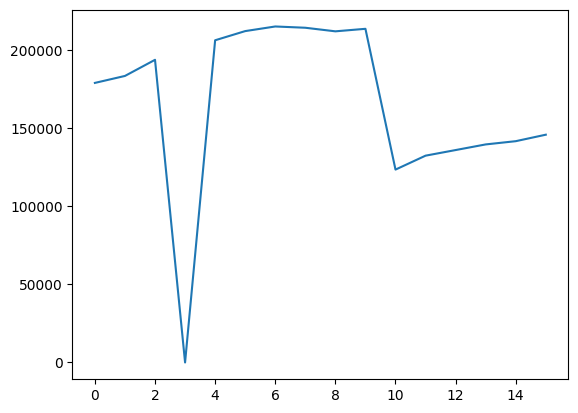

In [207]:
plt.plot(nbbat5)

In [82]:
#### Code à intégrer au précédent : transition d'isolé à cluster d'une année sur l'autre
## On joint la colonne id_cluster de l'année -1 sur la colonne id, et on garde les observations qui étaient à -1 l'année passée et différent de -1 sur l'année suivnate.

df_conv = gdf_meta.merge(gdf_meta_moins1["ID", "id_cluster"], on="ID", how="left", suffixes=("", "_ancien")) ## gdf qui contient aussi l'information sur la bat était un cluster l'année précédente
nbconv1.append(len(df_conv[ (df_conv["id_cluster"]!=-1) & (df_conv["id_cluster_ancien"]==-1),:])) ## On compte tous les bat qui passent d'isolé à cluster 


{'n_clusters_lvl1': 8849,
 'n_noise_lvl1': 148864,
 'n_meta_clusters': 312,
 'n_meta_noise': 3555}

In [98]:
##### On somme et on fait les statistiques descriptives

## nombre clusters
nbclust = [sum(x) for x in zip(nbclust1, nbclust2, nbclust3, nbclust4, nbclust5)]

## nombre de meta clusters
nbmeta = [sum(x) for x in zip(nbmeta1, nbmeta2, nbmeta3, nbmeta4, nbmeta5)]

## surface totale
surf = [sum(x) for x in zip(surf1, surf2, surf3, surf4, surf5)]

## nombre d'isolés
nbisole = [sum(x) for x in zip(nbisole1, nbisole2, nbisole3, nbisole4, nbisole5)]

## Nombre de conversions


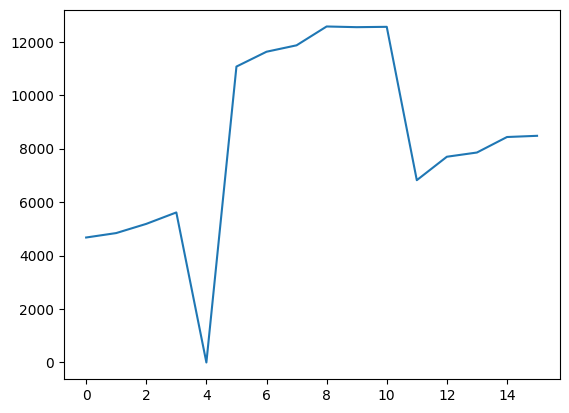

In [208]:
plt.plot(nbclust1)

## Calcul des paramètres optimaux epsilon et min_sample
Pour chaque valeur de min_sample, on cherche le maximum de la dérivée seconde, cela nous permet donc de déduire le meilleur epsilon. On cherche ensuite le min_sample qui mène au coude le plus prononcé. On a ainsi la meilleure paire

In [250]:
def derivee_seconde(y, dt=1):
    y = np.array(y, dtype=float)
    d2y = np.gradient(np.gradient(y, dt), dt)
    return d2y


import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

def dbscan_elbow(gdf, minPts=5, title="Méthode du coude pour DBSCAN"):
    # 1️⃣ Vérification des données
    if 'geometry' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")

    # 2️⃣ Reprojeter en coordonnées métriques si nécessaire (pour distances physiques)
    if gdf.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un système de coordonnées défini (CRS).")
    if not gdf.crs.is_projected:
        print("⚠️ Projection en EPSG:3857 pour obtenir des distances en mètres.")
        gdf = gdf.to_crs(epsg=3857)

    # 3️⃣ Extraire les coordonnées des points
    coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))

    # 4️⃣ Calcul du k-ième voisin
    k = minPts - 1
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # 5️⃣ Trier les distances du k-ième plus proche voisin
    distances = np.sort(distances[:, k-1])

    # 6️⃣ Tracer la courbe du coude
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.title(f"{title} (k = {k})")
    plt.xlabel("Points triés par distance croissante")
    plt.ylabel(f"Distance au {k}-ième plus proche voisin (mètres)")
    plt.grid(True)
    plt.show()

    return distances

def dbscan_elbow_courbe(gdf, minPts=5, title="Méthode du coude pour DBSCAN"):
    # 1️⃣ Vérification des données
    if 'geometry' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")

    # 2️⃣ Reprojeter en coordonnées métriques si nécessaire (pour distances physiques)
    if gdf.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un système de coordonnées défini (CRS).")
    if not gdf.crs.is_projected:
        print("⚠️ Projection en EPSG:3857 pour obtenir des distances en mètres.")
        gdf = gdf.to_crs(epsg=3857)

    # 3️⃣ Extraire les coordonnées des points
    coords = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))

    # 4️⃣ Calcul du k-ième voisin
    k = minPts - 1
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # 5️⃣ Trier les distances du k-ième plus proche voisin
    distances = np.sort(distances[:, k-1])

    # 6️⃣ Tracer la courbe du coude
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.xlim(2500000, 3000000) 
    plt.title(f"{title} (k = {k+1})")
    plt.xlabel("Points triés par distance croissante")
    plt.xscale("log")
    plt.ylabel(f"Distance au {k}-ième plus proche voisin (mètres)")
    plt.grid(True)
    plt.show()

    return distances

def dbscan_elbow_courbe_meta(gdf, minPts=5, title="Méthode du coude pour DBSCAN Meta"):
    # 1️⃣ Vérification des données
    if 'barycentre' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")

    # 2️⃣ Reprojeter en coordonnées métriques si nécessaire (pour distances physiques)
    if gdf.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un système de coordonnées défini (CRS).")
    if not gdf.crs.is_projected:
        print("⚠️ Projection en EPSG:3857 pour obtenir des distances en mètres.")
        gdf = gdf.to_crs(epsg=3857)

    # 3️⃣ Extraire les coordonnées des points
    coords = np.unique(np.array(list(zip(gdf.barycentre.x, gdf.barycentre.y))),axis = 0)

    # 4️⃣ Calcul du k-ième voisin
    k = minPts - 1
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(coords)
    distances, indices = nbrs.kneighbors(coords)

    # 5️⃣ Trier les distances du k-ième plus proche voisin
    distances = np.sort(distances[:, k-1])

    # 6️⃣ Tracer la courbe du coude
    plt.figure(figsize=(8, 5))
    plt.plot(distances)
    plt.title(f"{title} (k = {k+1})")
    plt.xlabel("Points triés par distance croissante")
    plt.xscale("log")
    plt.ylabel(f"Distance au {k}-ième plus proche voisin (mètres)")
    plt.grid(True)
    plt.show()

    return distances


In [248]:
coords = np.unique(np.array(list(zip(gdf_meta_clust.barycentre.x, gdf_meta_clust.barycentre.y))),axis = 0)

# 4️⃣ Calcul du k-ième voisin
k = 4
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(coords)
distances, indices = nbrs.kneighbors(coords)

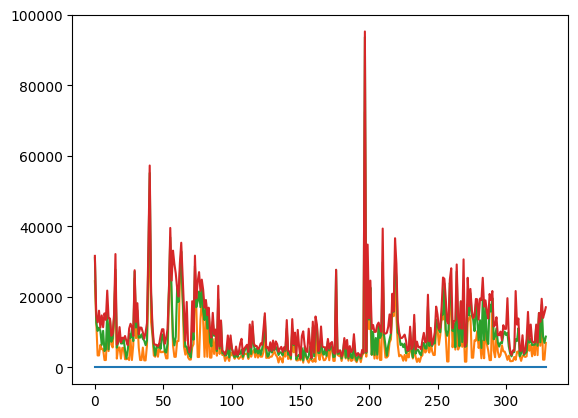

In [249]:
plt.plot(distances)

In [245]:
np.unique(coords,axis = 0)

array([[ 301516.06807222, 6665754.003794  ],
       [ 314792.12339083, 6645173.86669964],
       [ 322556.01700964, 6634999.88490668],
       [ 325313.71966969, 6632991.51332249],
       [ 327538.2255317 , 6644078.08411359],
       [ 328590.14682448, 6650401.62331748],
       [ 331232.6546329 , 6654877.84784028],
       [ 332888.54560452, 6611114.23308888],
       [ 333501.47618614, 6613128.84038298],
       [ 334912.86613509, 6664593.1045019 ],
       [ 337311.08794905, 6609702.97026907],
       [ 343609.77470272, 6622086.43397322],
       [ 354862.29821445, 6629802.17103691],
       [ 356952.35226936, 6639219.74025479],
       [ 358030.94124405, 6658974.85443629],
       [ 359477.63529202, 6593017.69488317],
       [ 360658.51359874, 6626872.27308897],
       [ 361649.76470496, 6632412.88723234],
       [ 362066.78123003, 6641683.2509081 ],
       [ 362665.57630213, 6625353.71303837],
       [ 369053.32996155, 6627722.84920685],
       [ 369776.64106784, 6633223.4507892 ],
       [ 3

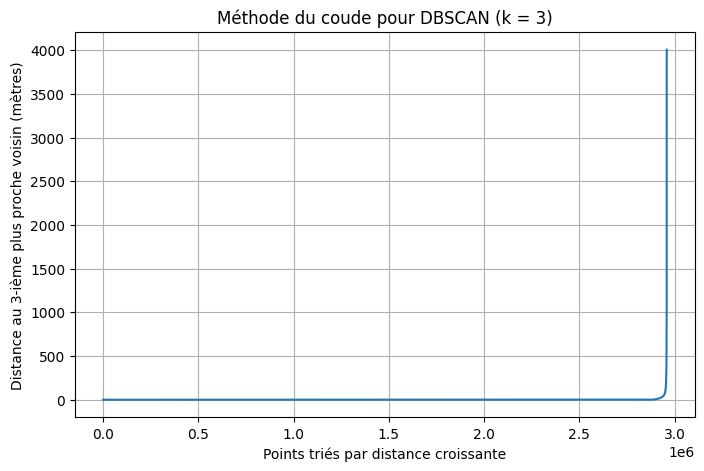

In [136]:
a = dbscan_elbow(gdf,minPts = 4)

(2800000, 3000000)

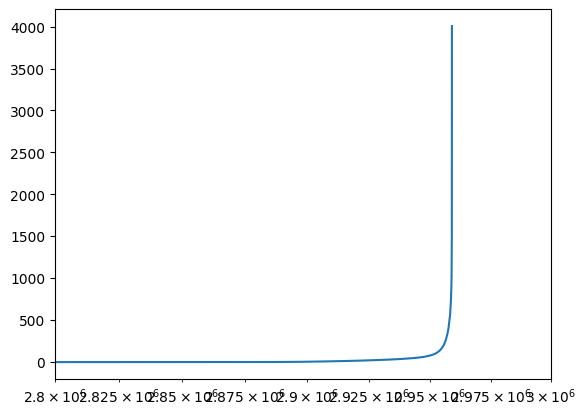

In [137]:
plt.plot(a)
plt.xscale("log")
plt.xlim(2800000, 3000000) 

In [128]:
from sklearn.metrics import silhouette_score

# coords = tableau des coordonnées (x, y)
coords = np.column_stack([test.geometry.centroid.x, test.geometry.centroid.y])
labels = test["id_cluster"]

# on exclut le bruit (-1)
mask = labels != -1
sil_score = silhouette_score(coords[mask], labels[mask])
sil_score

0.8716200031631621

In [139]:
np.gradient(a)

array([  0.        ,   0.        ,   0.        , ...,  87.33824191,
       107.01101051,  56.1143716 ], shape=(2958999,))

In [140]:
import numpy as np

def moving_average(y, window_size=5):
    return np.convolve(y, np.ones(window_size)/window_size, mode='valid')


In [178]:
b = moving_average(a,window_size=10000)

In [179]:
c = np.gradient(np.gradient(b))

(2958000.0, 2960000.0)

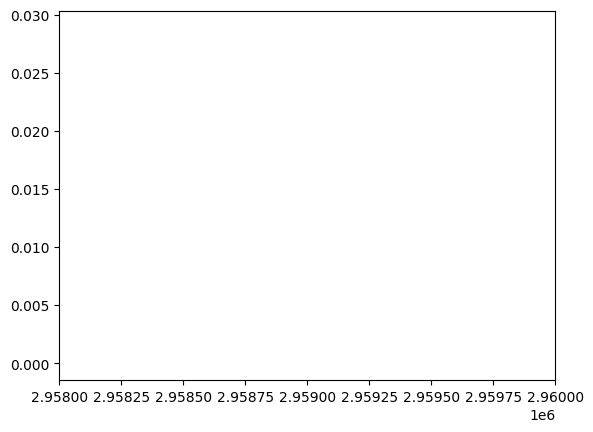

In [181]:
plt.plot(c)
plt.xlim(2958000, 2960000) 

In [182]:
!pip install kneed

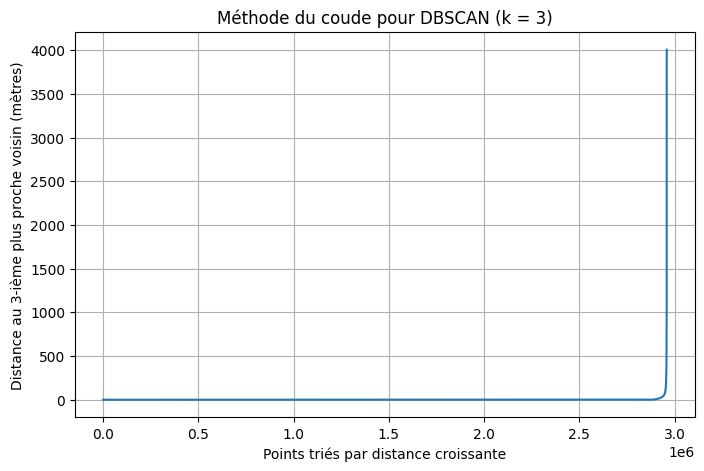

np.float64(1425.500074852785)

In [204]:
from kneed import KneeLocator
a = dbscan_elbow(gdf,minPts = 4)
x = np.arange(1, len(a) + 1)
y = a
knee = KneeLocator(x, y, curve='convex', direction='increasing')
a[knee.knee-1]

In [194]:
knee.knee

np.int64(2958999)

In [222]:
####
#### METHODE DU COUDE SUR LES METACLUSTER
####



def ajouter_barycentre_par_metacluster(gdf, cluster_col="id_meta_cluster"):
    # 1️⃣ Vérifications de base
    if cluster_col not in gdf.columns:
        raise ValueError(f"La colonne '{cluster_col}' n'existe pas dans le GeoDataFrame.")
    if 'geometry' not in gdf.columns:
        raise ValueError("Le GeoDataFrame doit contenir une colonne 'geometry'.")
    
    gdf_copy = gdf.copy()
    
    # 2️⃣ Si géométries non projetées, avertir
    if gdf_copy.crs is None:
        raise ValueError("Le GeoDataFrame doit avoir un CRS défini pour calculer les barycentres.")
    if not gdf_copy.crs.is_projected:
        print("⚠️ Le CRS n'est pas projeté. Projection temporaire en EPSG:3857 pour le calcul en mètres.")
        gdf_copy = gdf_copy.to_crs(epsg=3857)
    
    # 3️⃣ Calcul des barycentres par groupe
    # Dissolve (fusionne) les géométries par méta-cluster
    barycentres = gdf_copy.dissolve(by=cluster_col, as_index=False)[[cluster_col, "geometry"]]
    
    # Calcul du centroïde de chaque groupe
    barycentres["barycentre"] = barycentres.geometry.centroid
    
    # 4️⃣ Fusion des barycentres avec le gdf original
    gdf_final = gdf_copy.merge(
        barycentres[[cluster_col, "barycentre"]],
        on=cluster_col,
        how="left"
    )
    
    return gdf_final
    

gdf_meta_clust = ajouter_barycentre_par_metacluster(gdf_meta)
dbscan_elbow_courbe_meta(gdf_meta_clust)

AttributeError: 'GeoSeries' object has no attribute 'barycentre'

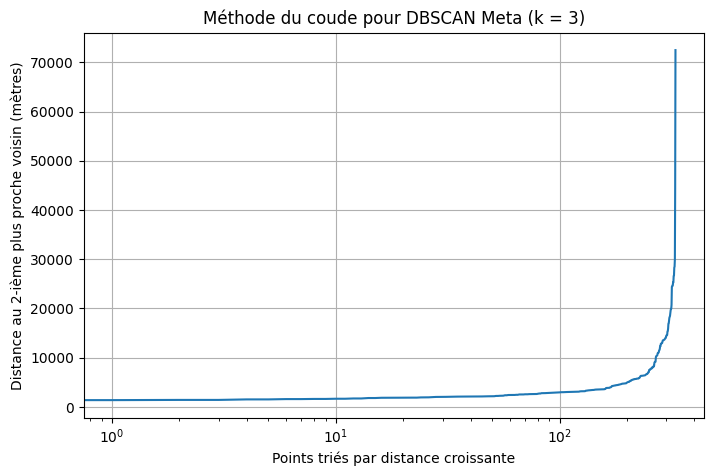

array([ 1363.4326021 ,  1363.4326021 ,  1405.64306939,  1405.64306939,
        1509.78884074,  1509.78884074,  1573.18143766,  1573.18143766,
        1604.37079191,  1604.37079191,  1644.2763151 ,  1644.2763151 ,
        1699.919142  ,  1699.919142  ,  1789.77878741,  1789.77878741,
        1839.93443167,  1839.93443167,  1853.95926162,  1853.95926162,
        1866.52461247,  1866.52461247,  1869.05509131,  1869.05509131,
        1914.59622733,  1914.59622733,  1930.63862401,  1980.09688652,
        2010.78318636,  2010.78318636,  2028.74191894,  2028.74191894,
        2046.50315725,  2046.50315725,  2076.92850568,  2076.92850568,
        2088.66417371,  2088.66417371,  2089.74126829,  2089.74126829,
        2105.78404575,  2105.78404575,  2106.07144962,  2106.07144962,
        2110.71541169,  2110.71541169,  2126.61943847,  2126.61943847,
        2142.91678697,  2142.91678697,  2156.4261721 ,  2156.4261721 ,
        2214.45396757,  2214.45396757,  2243.97538681,  2243.97538681,
      

In [255]:
dbscan_elbow_courbe_meta(gdf_meta_clust,minPts = 3)

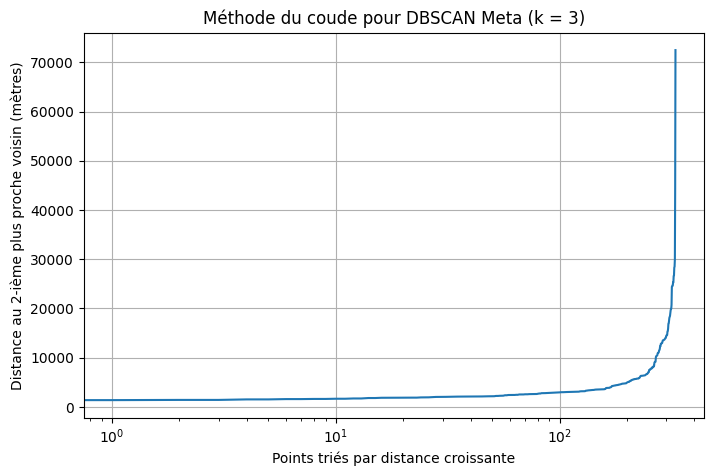

np.float64(24651.665533514366)

In [256]:
from kneed import KneeLocator
a = dbscan_elbow_courbe_meta(gdf_meta_clust,minPts = 3)
x = np.arange(1, len(a) + 1)
y = a
knee = KneeLocator(x, y, curve='convex', direction='increasing')
a[knee.knee-1]

## Métriques de  qualité du cluster

In [195]:
from sklearn.metrics import silhouette_score
#### Silhouette_score

# coords = tableau des coordonnées (x, y)
coords = np.column_stack([test.geometry.centroid.x, test.geometry.centroid.y])
labels = test["id_cluster"]

# on exclut le bruit (-1)
mask = labels != -1
sil_score = silhouette_score(coords[mask], labels[mask])
sil_score

#### 

import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

def grid_search_dbscan(X, eps_list, min_samples_list,
                       max_noise=0.3, min_clusters=2):
    best = None
    results = []
    for ms in min_samples_list:
        for eps in eps_list:
            lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
            n_noise = np.mean(lab == -1)
            n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
            sil = np.nan
            if n_clusters >= min_clusters and n_noise <= max_noise:
                mask = lab != -1
                if mask.sum() > n_clusters:  # au moins 1 point/cluster
                    sil = silhouette_score(X[mask], lab[mask])
            row = dict(eps=eps, min_samples=ms,
                       silhouette=sil, noise=n_noise, n_clusters=n_clusters)
            results.append(row)
            if not np.isnan(sil):
                if best is None or sil > best["silhouette"]:
                    best = row
    return best, results


In [ ]:
Coordo = np.column_stack([
    gdf.geometry.centroid.x,
    gdf.geometry.centroid.y
])

li_ep = [x*40  for x in range(1,100)]
meilleur , swag = grid_search_dbscan(Coordo, eps_list = li_ep, min_samples_list = range(1,20))
